In [9]:
!pip install tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\LAPTOP MSI\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


# DOWLOAD TENSORFLOW

In [13]:
import sys
import os

# Membungkus path dengan tanda kutip ganda untuk menangani spasi
python_path = f'"{sys.executable}"'
!{python_path} -m pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached keras-3.15.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Persiapan Dataset & Data Augmentation

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

# Konfigurasi Direktori (Sesuaikan dengan lokasi ekstraksi dataset Kaggle Anda)
base_dir = 'C:/Users/LAPTOP MSI/Downloads/archive (1)/TrashType_Image_Dataset'

# Data Augmentation untuk mengatasi overfitting (Slide 8)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Membagi otomatis untuk data validasi
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Load Dataset
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


2. Membangun Model dengan Strategi Fixed Feature Extractor

In [17]:
# Menggunakan VGG16 sebagai pre-trained model (Slide 8)
base_model = tf.keras.applications.VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# STRATEGI: Freeze pre-trained layers untuk mencegah overfitting (Slide 5, 6)
base_model.trainable = False

# Modifikasi bagian Classifier / Dense Layers (Slide 6, 69)
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Teknik tambahan penanganan overfitting
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Diubah ke nama loss yang benar
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

3. Proses Training 

In [18]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 718s 11s/step - accuracy: 0.3295 - loss: 2.0571 - val_accuracy: 0.5586 - val_loss: 1.2089
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 679s 11s/step - accuracy: 0.4333 - loss: 1.3780 - val_accuracy: 0.6581 - val_loss: 1.1013
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 465s 7s/step - accuracy: 0.5084 - loss: 1.2412 - val_accuracy: 0.6501 - val_loss: 0.9907
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 407s 6s/step - accuracy: 0.4936 - loss: 1.2378 - val_accuracy: 0.6938 - val_loss: 0.9667
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.5198 - loss: 1.1945 - val_accuracy: 0.6700 - val_loss: 0.9605
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.5390 - loss: 1.1239 - val_accuracy: 0.7316 - val_loss: 0.8718
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.5405 - loss: 1.1039 - val_accuracy: 0.6899 - val_loss: 0.8647
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.5558 - loss: 1.1050 - val_accuracy: 0.7376 -

4. Pengecekan Overfitting

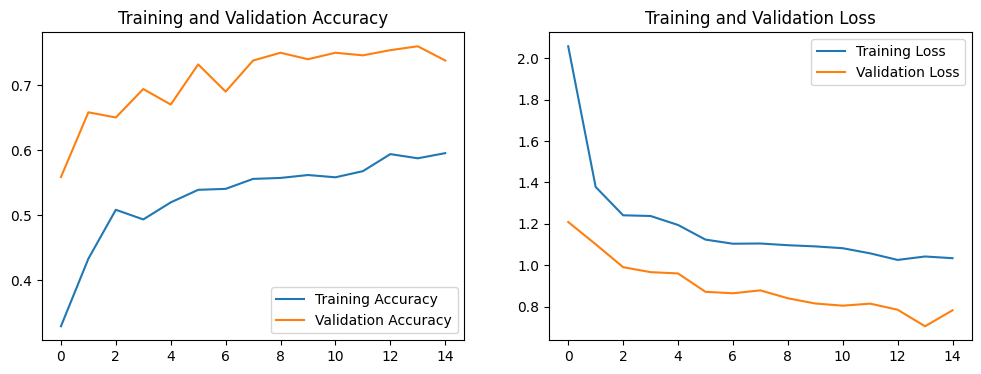

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# 1 Analisis Performa Model
Berdasarkan hasil training 15 epoch, model klasifikasi sampah menggunakan VGG16 ini menunjukkan performa yang Good Fit (Stabil) dan bebas dari overfitting:

Analisis Loss: Kurva Training Loss (turun ke 1.03) dan Validation Loss (turun ke 0.78) bergerak searah dan konsisten menurun. Hal ini membuktikan model tidak menghafal data latih.

Analisis Akurasi: Akurasi training mencapai 59.54% dan akurasi validasi stabil di angka 73.76%. Nilai validasi yang lebih tinggi ini wajar terjadi karena adanya teknik Data Augmentation yang membuat data training sengaja dibuat lebih menantang untuk dipelajari model.

# 2 Evaluasi Overfitting
Model dinyatakan aman tanpa perlu penanganan overfitting tambahan karena dua strategi yang diterapkan dari materi kuliah sudah bekerja optimal:

Freezing Layers: Membekukan layer konvolusi VGG16 agar fokus pada ekstraksi fitur dasar.

Dropout Layer: Penggunaan Dropout 0.5 terbukti sukses menahan laju overfitting.